#### Analysis of Fuel Price for Asia

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.width', 120)
PALETTE_REGION = {'South Asia': '#E63946', 'East Asia': '#457B9D', 'Southeast Asia': '#2A9D8F'}
PALETTE_SUBSIDY = {True: '#F4A261', False: '#2A9D8F'}
BG_COLOR  = '#FAFAFA'
GRID_COLOR = '#E8E8E8'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        False,
    'grid.color':       GRID_COLOR,
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

In [2]:
df = pd.read_csv("../Project_2/data_kaggle/asia_fuel_prices_detailed.csv")

print(df.head())

      country  sub_region iso3  gasoline_usd_per_liter  diesel_usd_per_liter  lpg_usd_per_kg  avg_monthly_income_usd  \
0    Pakistan  South Asia  PAK                   1.640                 1.860           1.250                     180   
1       India  South Asia  IND                   1.110                 1.030           1.080                     280   
2  Bangladesh  South Asia  BGD                   1.070                 0.930           0.980                     160   
3   Sri Lanka  South Asia  LKA                   1.340                 1.190           1.180                     210   
4       Nepal  South Asia  NPL                   1.340                 1.210           1.280                     120   

   fuel_affordability_index  oil_import_dependency_pct  refinery_capacity_kbpd  ev_adoption_pct  fuel_subsidy_active  \
0                     3.700                         85                     450            0.400                 True   
1                     8.400            

In [3]:
print(f'Shape        : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Countries    : {df["country"].nunique()}')
print(f'Sub-Regions  : {df["sub_region"].nunique()} → {list(df["sub_region"].unique())}')
print(f'Price Date   : {df["price_date"].unique()[0]}')
print(f'Missing Values: {df.isnull().sum().sum()}')

Shape        : 22 rows × 16 columns
Countries    : 22
Sub-Regions  : 3 → ['South Asia', 'East Asia', 'Southeast Asia']
Price Date   : 2026-04-04
Missing Values: 0


In [4]:
df.head(10)

,country,sub_region,iso3,gasoline_usd_per_liter,diesel_usd_per_liter,lpg_usd_per_kg,avg_monthly_income_usd,fuel_affordability_index,oil_import_dependency_pct,refinery_capacity_kbpd,ev_adoption_pct,fuel_subsidy_active,subsidy_cost_bn_usd,co2_transport_mt,price_date,gasoline_pct_daily_wage
0,Pakistan,South Asia,PAK,1.640,1.860,1.250,180,3.700,85,450,0.400,True,5.200,42.500,2026-04-04,27.300
1,India,South Asia,IND,1.110,1.030,1.080,280,8.400,85,5340,2.400,True,8.500,325.000,2026-04-04,11.900
2,Bangladesh,South Asia,BGD,1.070,0.930,0.980,160,5.000,100,33,0.100,True,2.800,16.200,2026-04-04,20.100
3,Sri Lanka,South Asia,LKA,1.340,1.190,1.180,210,5.200,100,50,0.200,False,0.000,8.500,2026-04-04,19.100
4,Nepal,South Asia,NPL,1.340,1.210,1.280,120,3.000,100,0,0.600,False,0.000,4.300,2026-04-04,33.500
5,Afghanistan,South Asia,AFG,0.860,0.810,0.850,60,2.300,100,0,0.000,False,0.000,2.900,2026-04-04,43.000
6,China,East Asia,CHN,1.260,1.120,0.820,960,25.400,72,17840,10.200,False,0.000,990.000,2026-04-04,3.900
7,Japan,East Asia,JPN,1.150,1.040,1.200,3200,92.800,99,3520,3.500,True,8.200,182.000,2026-04-04,1.100
8,South Korea,East Asia,KOR,1.370,1.220,1.000,2800,68.100,97,3330,10.500,False,0.000,96.000,2026-04-04,1.500
9,Taiwan,East Asia,TWN,1.060,0.910,0.850,2200,69.200,98,1200,5.000,True,3.500,35.000,2026-04-04,1.400


In [7]:
df.describe(include='all')

,country,sub_region,iso3,gasoline_usd_per_liter,diesel_usd_per_liter,lpg_usd_per_kg,avg_monthly_income_usd,fuel_affordability_index,oil_import_dependency_pct,refinery_capacity_kbpd,ev_adoption_pct,fuel_subsidy_active,subsidy_cost_bn_usd,co2_transport_mt,price_date,gasoline_pct_daily_wage
count,22,22,22,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22.000,22,22.000,22.000,22,22.000
unique,22,3,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,1,NaN
top,Pakistan,Southeast Asia,PAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,2026-04-04,NaN
freq,1,11,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,22,NaN
mean,NaN,NaN,NaN,1.179,1.093,0.954,931.818,30.577,81.364,1695.818,2.164,NaN,3.091,95.732,NaN,14.577
std,NaN,NaN,NaN,0.427,0.360,0.252,1279.705,44.764,27.830,3871.026,3.199,NaN,5.140,214.339,NaN,13.044
min,NaN,NaN,NaN,0.390,0.230,0.300,60.000,2.300,0.000,0.000,0.000,NaN,0.000,0.400,NaN,0.500
25%,NaN,NaN,NaN,1.062,0.935,0.827,165.000,4.175,64.500,8.250,0.100,NaN,0.000,4.425,NaN,2.250
50%,NaN,NaN,NaN,1.195,1.070,0.965,295.000,8.500,98.500,320.000,0.450,NaN,0.000,26.250,NaN,11.800
75%,NaN,NaN,NaN,1.335,1.185,1.132,925.000,50.900,100.000,1305.000,3.325,NaN,4.775,73.250,NaN,23.900


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    22 non-null     object 
 1   sub_region                 22 non-null     object 
 2   iso3                       22 non-null     object 
 3   gasoline_usd_per_liter     22 non-null     float64
 4   diesel_usd_per_liter       22 non-null     float64
 5   lpg_usd_per_kg             22 non-null     float64
 6   avg_monthly_income_usd     22 non-null     int64  
 7   fuel_affordability_index   22 non-null     float64
 8   oil_import_dependency_pct  22 non-null     int64  
 9   refinery_capacity_kbpd     22 non-null     int64  
 10  ev_adoption_pct            22 non-null     float64
 11  fuel_subsidy_active        22 non-null     bool   
 12  subsidy_cost_bn_usd        22 non-null     float64
 13  co2_transport_mt           22 non-null     float64
 

In [8]:
df['price_date'] = pd.to_datetime(df['price_date'])

In [9]:
df['daily_income_usd']         = df['avg_monthly_income_usd'] / 30
df['fuel_cost_10L_pct_income'] = (df['gasoline_usd_per_liter'] * 10) / df['avg_monthly_income_usd'] * 100
df['diesel_gasoline_ratio']    = df['diesel_usd_per_liter'] / df['gasoline_usd_per_liter']
df['subsidy_per_capita_usd']   = (df['subsidy_cost_bn_usd'] * 1e9) / (df['co2_transport_mt'] + 1)  # proxy
df['co2_per_income_unit']      = df['co2_transport_mt'] / (df['avg_monthly_income_usd'] + 1)
df['refinery_self_sufficiency']= 100 - df['oil_import_dependency_pct']

In [10]:
print('Derived columns added:')
derived_cols = ['daily_income_usd','fuel_cost_10L_pct_income','diesel_gasoline_ratio',
                'refinery_self_sufficiency']
print(df[['country'] + derived_cols].to_string(index=False))

Derived columns added:
    country  daily_income_usd  fuel_cost_10L_pct_income  diesel_gasoline_ratio  refinery_self_sufficiency
   Pakistan             6.000                     9.111                  1.134                         15
      India             9.333                     3.964                  0.928                         15
 Bangladesh             5.333                     6.688                  0.869                          0
  Sri Lanka             7.000                     6.381                  0.888                          0
      Nepal             4.000                    11.167                  0.903                          0
Afghanistan             2.000                    14.333                  0.942                          0
      China            32.000                     1.312                  0.889                         28
      Japan           106.667                     0.359                  0.904                          1
South Korea            

In [11]:
num_cols = ['gasoline_usd_per_liter','diesel_usd_per_liter','lpg_usd_per_kg',
            'avg_monthly_income_usd','fuel_affordability_index','gasoline_pct_daily_wage']

stats = df[num_cols].agg(['mean','median','std','min','max']).T
stats.columns = ['Mean','Median','Std Dev','Min','Max']
print('=== Core Statistical Summary ===')
print(stats.round(3).to_string())

=== Core Statistical Summary ===
                            Mean  Median  Std Dev    Min      Max
gasoline_usd_per_liter     1.179   1.195    0.427  0.390    2.530
diesel_usd_per_liter       1.093   1.070    0.360  0.230    2.050
lpg_usd_per_kg             0.954   0.965    0.252  0.300    1.350
avg_monthly_income_usd   931.818 295.000 1279.705 60.000 4800.000
fuel_affordability_index  30.577   8.500   44.764  2.300  188.000
gasoline_pct_daily_wage   14.577  11.800   13.044  0.500   43.000


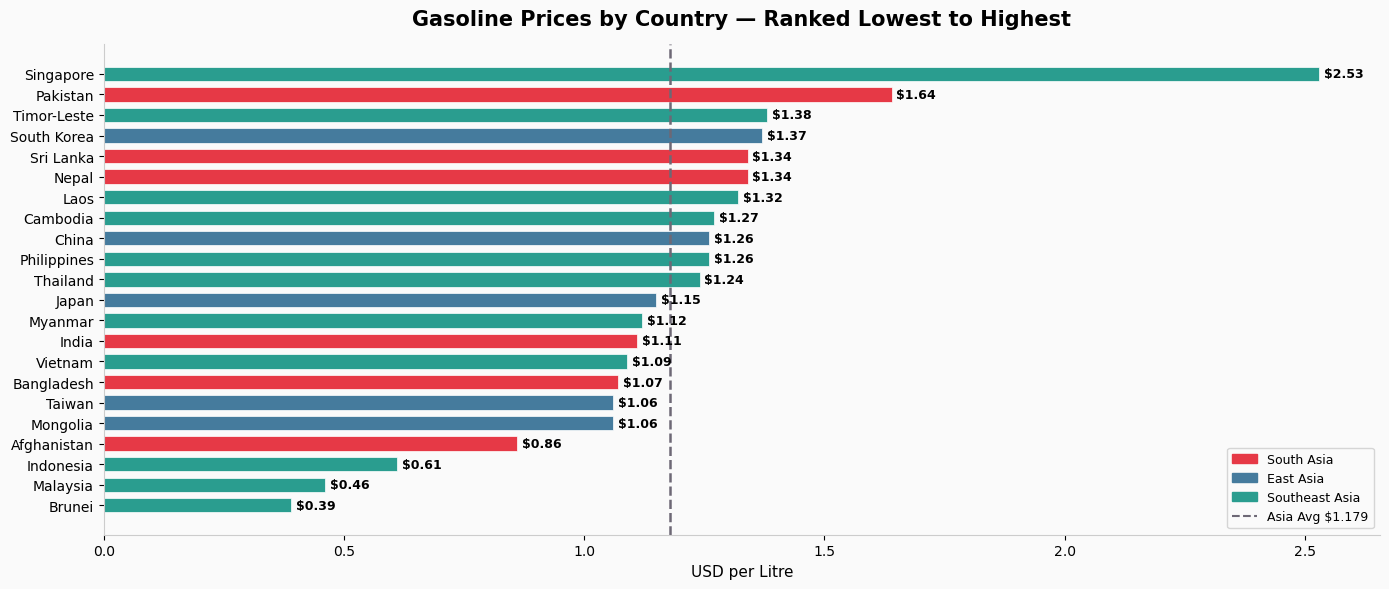

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
sorted_df = df.sort_values('gasoline_usd_per_liter')
colors = [PALETTE_REGION[r] for r in sorted_df['sub_region']]

bars = ax.barh(sorted_df['country'], sorted_df['gasoline_usd_per_liter'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

for bar, val in zip(bars, sorted_df['gasoline_usd_per_liter']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')

avg = df['gasoline_usd_per_liter'].mean()
ax.axvline(avg, color='#6D6875', linestyle='--', linewidth=1.8, label=f'Asia Avg: ${avg:.3f}')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
legend_patches.append(plt.Line2D([0],[0], color='#6D6875', linestyle='--', label=f'Asia Avg ${avg:.3f}'))
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.8)

ax.set_title('Gasoline Prices by Country — Ranked Lowest to Highest', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('USD per Litre', fontsize=11)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

In [13]:
print('Top 5 Most Affordable Countries (Fuel Affordability Index):')
print(df.nlargest(5, 'fuel_affordability_index')[['country','sub_region','fuel_affordability_index','avg_monthly_income_usd','gasoline_usd_per_liter']].to_string(index=False))

print('\nTop 5 Least Affordable Countries:')
print(df.nsmallest(5, 'fuel_affordability_index')[['country','sub_region','fuel_affordability_index','avg_monthly_income_usd','gasoline_usd_per_liter']].to_string(index=False))

print('\nGasoline as % of Daily Wage — Top 5 Most Burdened:')
print(df.nlargest(5, 'gasoline_pct_daily_wage')[['country','sub_region','gasoline_pct_daily_wage','avg_monthly_income_usd']].to_string(index=False))

Top 5 Most Affordable Countries (Fuel Affordability Index):
    country     sub_region  fuel_affordability_index  avg_monthly_income_usd  gasoline_usd_per_liter
     Brunei Southeast Asia                   188.000                    2200                   0.390
      Japan      East Asia                    92.800                    3200                   1.150
     Taiwan      East Asia                    69.200                    2200                   1.060
South Korea      East Asia                    68.100                    2800                   1.370
  Singapore Southeast Asia                    63.200                    4800                   2.530

Top 5 Least Affordable Countries:
    country     sub_region  fuel_affordability_index  avg_monthly_income_usd  gasoline_usd_per_liter
Afghanistan     South Asia                     2.300                      60                   0.860
Timor-Leste Southeast Asia                     2.900                     120                   1.

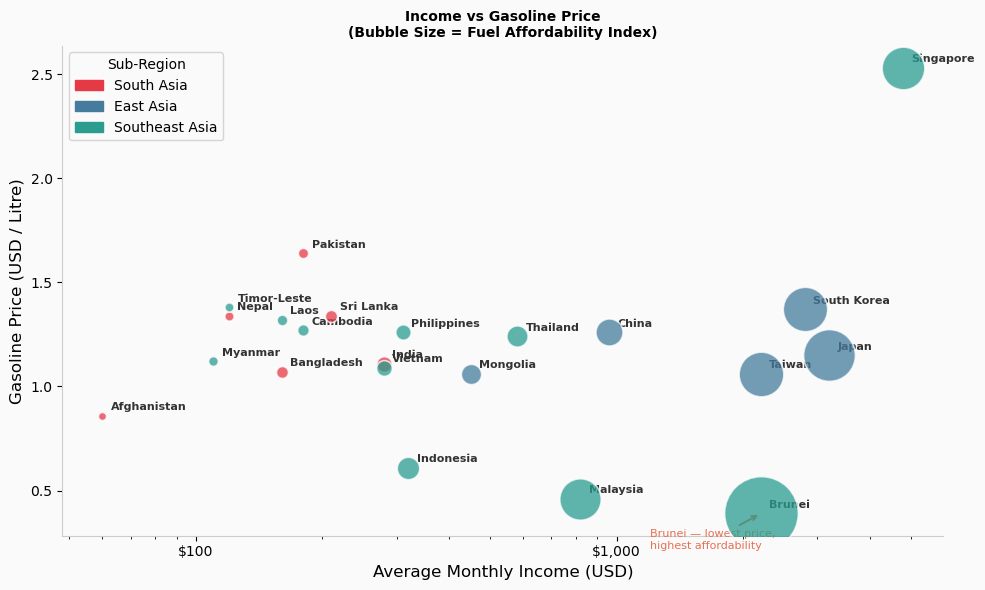

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in df.iterrows():
    color = PALETTE_REGION[row['sub_region']]
    size  = row['fuel_affordability_index'] * 15
    ax.scatter(row['avg_monthly_income_usd'], row['gasoline_usd_per_liter'],
               s=size, color=color, alpha=0.75, edgecolors='white', linewidth=1.2, zorder=5)
    ax.annotate(row['country'],
                (row['avg_monthly_income_usd'], row['gasoline_usd_per_liter']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='#333333', fontweight='bold')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in PALETTE_REGION.items()]
ax.legend(handles=legend_patches, fontsize=10, title='Sub-Region', title_fontsize=10)
ax.set_xlabel('Average Monthly Income (USD)', fontsize=12)
ax.set_ylabel('Gasoline Price (USD / Litre)', fontsize=12)
ax.set_title('Income vs Gasoline Price\n(Bubble Size = Fuel Affordability Index)', fontsize=10, fontweight='bold')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

brunei = df[df['country'] == 'Brunei'].iloc[0]
ax.annotate('Brunei — lowest price,\nhighest affordability',
            xy=(brunei['avg_monthly_income_usd'], brunei['gasoline_usd_per_liter']),
            xytext=(1200, 0.22), fontsize=8, color='#E76F51',
            arrowprops=dict(arrowstyle='->', color='#E76F51', lw=1.5))

plt.tight_layout()
plt.show()

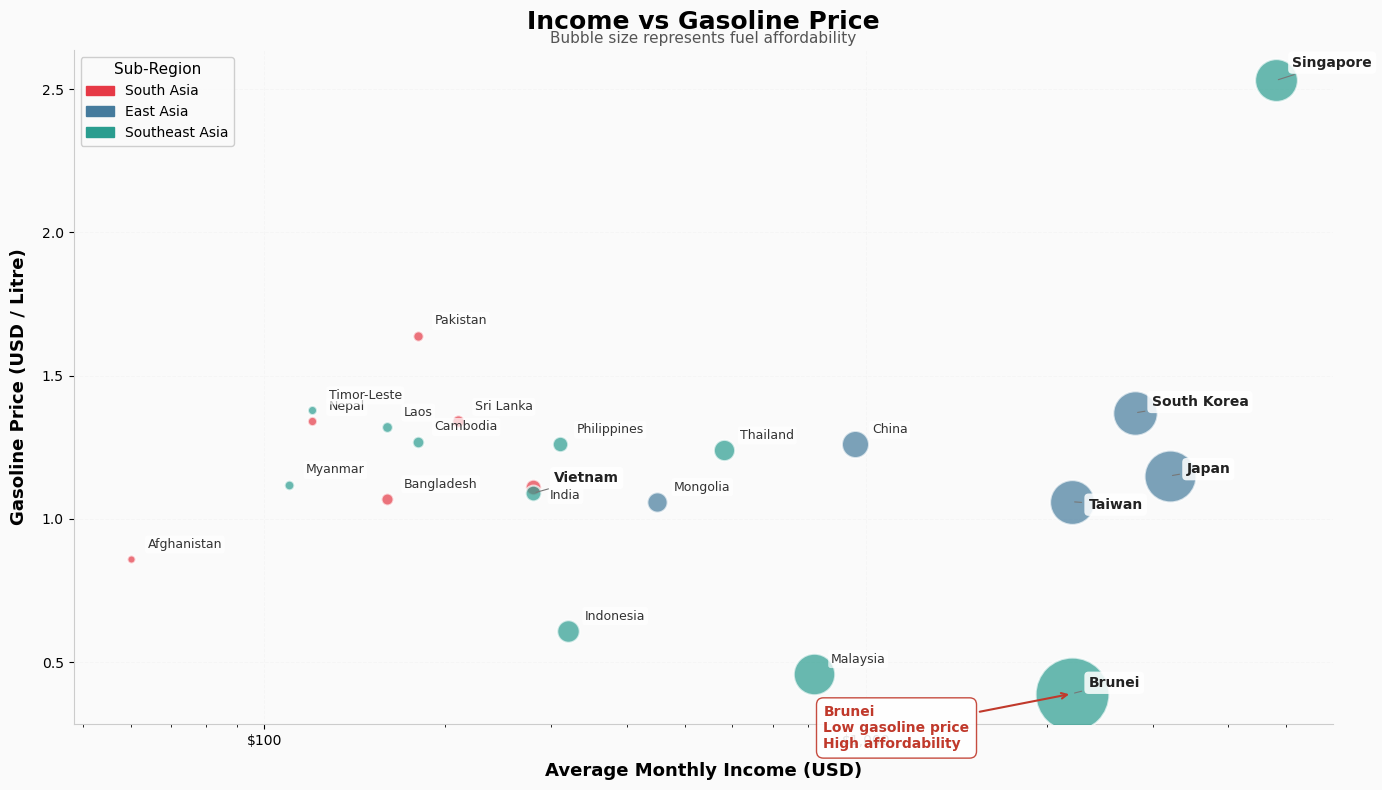

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 8))

# -----------------------------
# Plot bubbles
# -----------------------------
for _, row in df.iterrows():

    color = PALETTE_REGION[row['sub_region']]
    size = row['fuel_affordability_index'] * 15

    ax.scatter(
        row['avg_monthly_income_usd'],
        row['gasoline_usd_per_liter'],
        s=size,
        color=color,
        alpha=0.70,
        edgecolors='white',
        linewidth=1.5,
        zorder=3
    )

# -----------------------------
# Custom label positions
# -----------------------------
label_offsets = {
    'Singapore': (12, 10),
    'South Korea': (12, 5),
    'Japan': (12, 2),
    'Taiwan': (12, -5),

    'Vietnam': (15, 8),
    'India': (12, -8),

    'China': (12, 8),
    'Thailand': (12, 8),
    'Philippines': (12, 8),

    'Indonesia': (12, 8),
    'Malaysia': (12, 8),
    'Brunei': (12, 5),

    'Pakistan': (12, 8),
    'Sri Lanka': (12, 8),
    'Nepal': (12, 8),
    'Bangladesh': (12, 8),
    'Myanmar': (12, 8),
    'Cambodia': (12, 8),
    'Laos': (12, 8),
    'Timor-Leste': (12, 8),
    'Mongolia': (12, 8),
    'Afghanistan': (12, 8)
}

# -----------------------------
# Country labels
# -----------------------------
for _, row in df.iterrows():

    country = row['country']

    dx, dy = label_offsets.get(country, (8, 5))

    # Highlight selected countries
    if country in ['Singapore', 'South Korea', 'Japan', 'Taiwan', 'Vietnam', 'Brunei']:

        ax.annotate(
            country,
            (
                row['avg_monthly_income_usd'],
                row['gasoline_usd_per_liter']
            ),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            color='#222222',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor='none',
                alpha=0.85
            ),
            arrowprops=dict(
                arrowstyle='-',
                color='#777777',
                lw=0.8
            ),
            zorder=10
        )

    else:

        ax.annotate(
            country,
            (
                row['avg_monthly_income_usd'],
                row['gasoline_usd_per_liter']
            ),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=9,
            color='#333333',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='none',
                alpha=0.70
            ),
            zorder=8
        )

# -----------------------------
# Legend
# -----------------------------
legend_patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in PALETTE_REGION.items()
]

ax.legend(
    handles=legend_patches,
    title='Sub-Region',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    frameon=True,
    framealpha=0.95
)

# -----------------------------
# Axis labels
# -----------------------------
ax.set_xlabel(
    'Average Monthly Income (USD)',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

ax.set_ylabel(
    'Gasoline Price (USD / Litre)',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

# -----------------------------
# Title
# -----------------------------
ax.set_title(
    'Income vs Gasoline Price',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.text(
    0.5,
    1.01,
    'Bubble size represents fuel affordability',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color='#555555'
)

# -----------------------------
# Log scale
# -----------------------------
ax.set_xscale('log')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'${int(x):,}'
    )
)

# -----------------------------
# Grid
# -----------------------------
ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

# -----------------------------
# Brunei annotation
# -----------------------------
brunei = df[df['country'] == 'Brunei'].iloc[0]

ax.annotate(
    'Brunei\nLow gasoline price\nHigh affordability',
    xy=(
        brunei['avg_monthly_income_usd'],
        brunei['gasoline_usd_per_liter']
    ),
    xytext=(850, 0.20),
    fontsize=10,
    fontweight='bold',
    color='#C0392B',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='#C0392B',
        alpha=0.9
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='#C0392B',
        lw=1.5
    )
)

# -----------------------------
# Layout
# -----------------------------
plt.tight_layout()

# High resolution for presentation
plt.savefig(
    'income_vs_gasoline_price.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()